In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('./data/cars_env.csv')
df.head()

,veh id,manufacturer,nameplate,model,CVCM class,EPA class,fleet type,fuel type,footprint,baseline price,baseline mpg,baseline sales,predicted mpg
0,1,HONDA,Acura,MDX 4WD,11,SUV,T,G,50.8,45706.20000,22.052700,57380.0,23.011100
1,2,HONDA,Acura,RDX,11,SUV,T,G,45.1,34588.20000,24.174500,21271.0,26.457747
2,3,HONDA,Acura,RL,4,MIDSIZE CARS,C,G,47.6,47934.90000,24.562900,5132.0,23.773800
3,4,HONDA,Acura,TL,4,MIDSIZE CARS,C,G,47.8,35217.81622,27.068237,56720.0,26.884192
4,5,HONDA,Acura,TSX,3,COMPACT CARS,C,G,46.0,29483.10000,29.855173,21996.0,31.871653


In [5]:
df['EPA class'].value_counts()

EPA class
SUV                       160
SUBCOMPACT CARS            77
MIDSIZE CARS               65
STANDARD PICKUP TRUCKS     53
COMPACT CARS               47
LARGE CARS                 37
TWO SEATERS                27
SMALL PICKUP TRUCKS        18
SMALL STATION WAGONS       15
VANS                       13
MINIVAN                     7
MIDSIZE STATION WAGONS      5
Name: count, dtype: int64

In [11]:
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

y = df['EPA class'] #categorical column
x = df.loc[:, ['footprint', 'baseline price']]
u = x.apply(minmax) #scale our variable using the minmax scaler

df['footprint']

0      50.8
1      45.1
2      47.6
3      47.8
4      46.0
       ... 
519    43.5
520    48.1
521    48.0
522    50.1
523    50.1
Name: footprint, Length: 524, dtype: float64

In [12]:
from sklearn.neighbors import KNeighborsClassifier

# Set the number of neighbors, typically odd to "break ties":
k = 5 

# Create a fitted model instance:
model = KNeighborsClassifier(n_neighbors = k) # Create a model instance, not trained
model = model.fit(u,y) # Fit the model, trains it

# Make predictions:
y_hat = model.predict(u) # Hard prediction, we just get the EPA class
#y_hat = model.predict_proba(u) # soft prediction, we get a lists of probability for each epa class



In [14]:
pd.crosstab(y, y_hat, margins=True, normalize=True)

col_0,COMPACT CARS,LARGE CARS,MIDSIZE CARS,MINIVAN,SMALL PICKUP TRUCKS,SMALL STATION WAGONS,STANDARD PICKUP TRUCKS,SUBCOMPACT CARS,SUV,TWO SEATERS,VANS,All
EPA class,,,,,,,,,,,,
COMPACT CARS,0.049618,0.001908,0.009542,0.000000,0.000000,0.005725,0.000000,0.007634,0.015267,0.000000,0.000000,0.089695
LARGE CARS,0.003817,0.051527,0.003817,0.000000,0.000000,0.000000,0.000000,0.000000,0.011450,0.000000,0.000000,0.070611
MIDSIZE CARS,0.003817,0.009542,0.074427,0.000000,0.001908,0.000000,0.000000,0.009542,0.024809,0.000000,0.000000,0.124046
MIDSIZE STATION WAGONS,0.000000,0.001908,0.003817,0.000000,0.000000,0.000000,0.000000,0.001908,0.001908,0.000000,0.000000,0.009542
MINIVAN,0.000000,0.000000,0.001908,0.009542,0.000000,0.000000,0.000000,0.000000,0.001908,0.000000,0.000000,0.013359
SMALL PICKUP TRUCKS,0.000000,0.000000,0.001908,0.003817,0.028626,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.034351
SMALL STATION WAGONS,0.005725,0.000000,0.000000,0.000000,0.000000,0.015267,0.000000,0.001908,0.005725,0.000000,0.000000,0.028626
STANDARD PICKUP TRUCKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.097328,0.000000,0.003817,0.000000,0.000000,0.101145
SUBCOMPACT CARS,0.009542,0.000000,0.005725,0.000000,0.000000,0.005725,0.000000,0.108779,0.015267,0.001908,0.000000,0.146947


In [ ]:
model.score(u,y) # gives us the accuracy of the model

0.7137404580152672

In [ ]:
from sklearn.model_selection import train_test_split
u_train, u_test, y_train, y_test = train_test_split(u,y, # Feature and target variables
                                                    test_size=.2, # Split the sample 80 train/ 20 test
                                                    random_state=100) # For replication purposes

<Axes: >

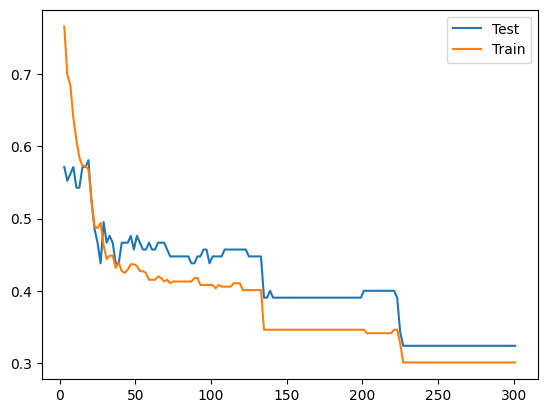

In [28]:
k_grid = np.array([ (2*k+3) for k in range(0,150)]) # Odd number grid
accuracies_test = []
accuracies_train = []
for k in k_grid: # For each candidate value of k...
    model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
    model = model.fit(u_train,y_train) # Fit the model
    accuracies_test.append(model.score(u_test, y_test)) # Save accuracy
    accuracies_train.append(model.score(u_train, y_train)) # Save accuracy

    
sns.lineplot(x=k_grid,y=accuracies_test, label="Test")
sns.lineplot(x=k_grid,y=accuracies_train, label="Train")

In [4]:
example = pd.read_csv('./data/ForeignGifts_edu.csv')
example.head()


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


<Axes: >

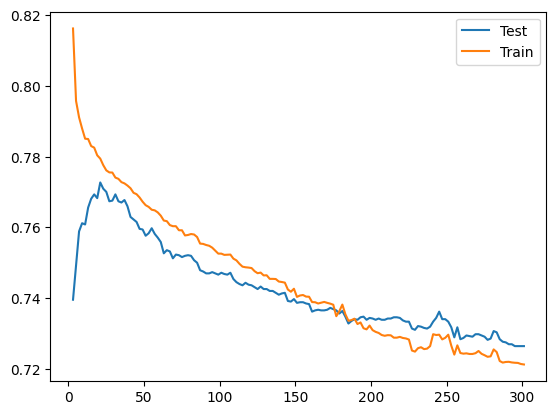

In [12]:
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

y = example['Gift Type'] #categorical column
x = example.loc[:, ['Foreign Gift Amount']]
u = x.apply(minmax) #scale our variable using the minmax scaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
u_train, u_test, y_train, y_test = train_test_split(u,y, # Feature and target variables
                                                    test_size=.2, # Split the sample 80 train/ 20 test
                                                    random_state=100) # For replication purposes


k_grid = np.array([ (2*k+3) for k in range(0,150)]) # Odd number grid
accuracies_test = []
accuracies_train = []
for k in k_grid: # For each candidate value of k...
    model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
    model = model.fit(u_train,y_train) # Fit the model
    accuracies_test.append(model.score(u_test, y_test)) # Save accuracy
    accuracies_train.append(model.score(u_train, y_train)) # Save accuracy

    
sns.lineplot(x=k_grid,y=accuracies_test, label="Test")
sns.lineplot(x=k_grid,y=accuracies_train, label="Train")